In [7]:
%pip install -q pybaseball pandas numpy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pybaseball import statcast


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from datetime import date
import meteostat as ms

point = ms.Point(27.76833, -82.65333)
start = date(2021, 1, 1)
end   = date(2024, 12, 31)

# 1) Find nearby stations
near = ms.stations.nearby(point, limit=50)

station_id = near.index[0]
print("Using station:", station_id)

# 4) Fetch daily data from that station id
df = ms.daily(station_id, start, end).fetch()
print(type(df))
print(df.head())

Using station: KSPG0
<class 'pandas.DataFrame'>
            temp  tmin  tmax  rhum  prcp  snwd  wspd  wpgt    pres  tsun  cldc
time                                                                          
2021-01-01  21.6  18.9  26.7    90   0.0  <NA>  15.3  <NA>  1019.3  <NA>  <NA>
2021-01-02  21.3  18.3  24.4    97   0.0  <NA>  15.7  <NA>  1018.4  <NA>  <NA>
2021-01-03  18.4  15.6  21.1    91  <NA>  <NA>  14.9  <NA>  1017.3  <NA>  <NA>
2021-01-04  14.5  11.7  17.8    74   0.0  <NA>  14.0  <NA>  1017.9  <NA>  <NA>
2021-01-05  15.8  12.8  20.0    76   0.0  <NA>   9.9  <NA>  1017.8  <NA>     0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Weather (given) ----
# df is your daily Meteostat weather dataframe for Tropicana Field (2021-2024)
weather = df.copy()

# Ensure datetime index
if not isinstance(weather.index, pd.DatetimeIndex):
    weather.index = pd.to_datetime(weather.index)

weather = weather.sort_index().loc["2021-01-01":"2024-12-31"]

# Normalize temperature column to 'temp' in °C
# Meteostat daily usually: tavg, tmin, tmax (°C)
if "tavg" in weather.columns:
    weather["temp"] = weather["tavg"]
elif {"tmin","tmax"}.issubset(weather.columns):
    weather["temp"] = (weather["tmin"] + weather["tmax"]) / 2
elif "temp" not in weather.columns:
    raise ValueError("Weather df needs tavg or (tmin,tmax) or temp column")

# Normalize other common columns (if present)
# Meteostat daily often: wspd (km/h), pres (hPa), rhum (%)
if "wspd" in weather.columns and "wind" not in weather.columns:
    weather["wind"] = weather["wspd"]
if "pres" in weather.columns and "pressure" not in weather.columns:
    weather["pressure"] = weather["pres"]
if "rhum" in weather.columns and "humidity" not in weather.columns:
    weather["humidity"] = weather["rhum"]

# Keep only what we need
keep_cols = [c for c in ["temp","wind","pressure","humidity"] if c in weather.columns]
weather = weather[keep_cols].copy()

weather.head()


,temp,wind,pressure,humidity
time,,,,
2021-01-01,22.8,15.3,1019.3,90
2021-01-02,21.35,15.7,1018.4,97
2021-01-03,18.35,14.9,1017.3,91
2021-01-04,14.75,14.0,1017.9,74
2021-01-05,16.4,9.9,1017.8,76


In [ ]:
# def rays_home_games_from_statcast(year):
#     # Pull a season window
#     sc = statcast(f"{year}-03-01", f"{year}-11-30")

#     # Rays home games only
#     sc = sc[sc["home_team"] == "TB"].copy()

#     # Date
#     sc["date"] = pd.to_datetime(sc["game_date"]).dt.tz_localize(None)
#     sc["date_only"] = sc["date"].dt.date

#     # Opponent (away team since Rays are home)
#     sc["Opp"] = sc["away_team"]

#     # ---- Batting events (Rays batting only) ----
#     # batting_team exists in many versions; if not, fallback via inning_topbot + home_team logic
#     if "batting_team" in sc.columns:
#         bat = sc[sc["batting_team"] == "TB"].copy()
#     else:
#         # Fallback: when Rays are home, Rays bat in bottom innings
#         # inning_topbot is usually 'Top'/'Bot'
#         bat = sc[sc["inning_topbot"].str.lower().str.startswith("bot")].copy()

#     hit_events = {"single","double","triple","home_run"}
#     bb_events  = {"walk","intent_walk"}
#     so_events  = {"strikeout"}

#     bat["is_hit"] = bat["events"].isin(hit_events)
#     bat["is_hr"]  = bat["events"].eq("home_run")
#     bat["is_bb"]  = bat["events"].isin(bb_events)
#     bat["is_so"]  = bat["events"].isin(so_events)

#     batting = bat.groupby(["game_pk","date_only"], as_index=False).agg(
#         H=("is_hit","sum"),
#         HR=("is_hr","sum"),
#         BB=("is_bb","sum"),
#         SO=("is_so","sum"),
#     )

#     # ---- Runs for/against from game-level columns ----
#     # Statcast usually includes home_score / away_score repeated on rows
#     # We'll take max per game_pk
#     score_cols = [c for c in ["home_score","away_score"] if c in sc.columns]
#     if len(score_cols) == 2:
#         scores = sc.groupby(["game_pk","date_only","Opp"], as_index=False).agg(
#             R=("home_score","max"),
#             RA=("away_score","max"),
#         )
#     else:
#         # If missing, you can compute later from another source
#         scores = sc.groupby(["game_pk","date_only","Opp"], as_index=False).size()
#         scores["R"] = np.nan
#         scores["RA"] = np.nan
#         scores = scores.drop(columns=["size"])

#     games_y = scores.merge(batting, on=["game_pk","date_only"], how="left")
#     games_y["season"] = year

#     # Optional: Day/Night (if game start time exists)
#     # Some statcast pulls have "game_time" or "start_time"
#     dn = None
#     for c in ["game_time", "start_time", "game_time_et"]:
#         if c in sc.columns:
#             dn = c
#             break
#     if dn:
#         # crude: before 17:00 local -> day else night (you can refine)
#         # If it’s ET time string like '7:10', parse hour
#         times = sc.groupby("game_pk")[dn].agg(lambda x: x.dropna().astype(str).iloc[0] if len(x.dropna()) else None)
#         def to_dn(t):
#             if t is None: return np.nan
#             t = str(t)
#             # attempt parse 'HH:MM' or 'H:MM'
#             try:
#                 hour = int(t.split(":")[0])
#             except:
#                 return np.nan
#             return "D" if hour < 17 else "N"
#         dn_map = times.map(to_dn).reset_index().rename(columns={dn:"DN"})
#         games_y = games_y.merge(dn_map, on="game_pk", how="left")
#     else:
#         games_y["DN"] = np.nan

#     games_y["date"] = pd.to_datetime(games_y["date_only"])
#     return games_y

# games = pd.concat([rays_home_games_from_statcast(y) for y in [2021,2022,2023,2024]], ignore_index=True)
# games["HR_H_ratio"] = np.where(games["H"]>0, 100*games["HR"]/games["H"], np.nan)

# games = games.sort_values("date").reset_index(drop=True)
# games.head(), games.shape


This is a large query, it may take a moment to complete


c:\Users\mckha\Documents\Giants Capstone\.venv\Lib\site-packages\pybaseball\statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates


100%|██████████| 246/246 [00:44<00:00,  5.56it/s]


This is a large query, it may take a moment to complete


...

This is a large query, it may take a moment to complete


c:\Users\mckha\Documents\Giants Capstone\.venv\Lib\site-packages\pybaseball\statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates


100%|██████████| 246/246 [00:42<00:00,  5.72it/s]


(   game_pk   date_only  Opp  R  RA   H  HR  BB  SO  season  DN       date  \
 0   641594  2021-03-15  BOS  3   2   7   0   7   8    2021 NaN 2021-03-15   
 1   641881  2021-03-16  BAL  7   1   9   1   4   9    2021 NaN 2021-03-16   
 2   641755  2021-03-21  ATL  1  11   6   1   1   7    2021 NaN 2021-03-21   
 3   641695  2021-03-22  BOS  4  10   7   1   6  11    2021 NaN 2021-03-22   
 4   641595  2021-03-24  MIN  7   6  12   2   1   8    2021 NaN 2021-03-24   
 
    HR_H_ratio  
 0    0.000000  
 1   11.111111  
 2   16.666667  
 3   14.285714  
 4   16.666667  ,
 (355, 13))

In [39]:
import pandas as pd
import numpy as np
from pybaseball import statcast

def build_rays_home_games_statcast(year):
    sc = statcast(f"{year}-03-01", f"{year}-11-30")
    if len(sc) == 0:
        return pd.DataFrame()

    # Rays code in your data is TB
    sc = sc[sc["home_team"] == "TB"].copy()
    if len(sc) == 0:
        return pd.DataFrame()

    # date
    sc["date"] = pd.to_datetime(sc["game_date"])
    sc["date_only"] = sc["date"].dt.date

    # Opponent = away team (since Rays are home)
    sc["Opp"] = sc["away_team"]

    # Rays batting = bottom innings for home team
    bat = sc[sc["inning_topbot"].astype(str).str.lower().str.startswith("bot")].copy()

    hit_events = {"single","double","triple","home_run"}
    bb_events  = {"walk","intent_walk"}
    so_events  = {"strikeout"}

    bat["is_hit"] = bat["events"].isin(hit_events)
    bat["is_hr"]  = bat["events"].eq("home_run")
    bat["is_bb"]  = bat["events"].isin(bb_events)
    bat["is_so"]  = bat["events"].isin(so_events)

    batting = bat.groupby(["game_pk","date_only"], as_index=False).agg(
        H=("is_hit","sum"),
        HR=("is_hr","sum"),
        BB=("is_bb","sum"),
        SO=("is_so","sum"),
    )

    # Scores (max within game)
    scores = sc.groupby(["game_pk","date_only","Opp"], as_index=False).agg(
        R=("home_score","max"),
        RA=("away_score","max"),
    )

    g = scores.merge(batting, on=["game_pk","date_only"], how="left")
    g["season"] = year
    g["date"] = pd.to_datetime(g["date_only"])
    g["HR_H_ratio"] = np.where(g["H"] > 0, 100*g["HR"]/g["H"], np.nan)
    return g

games = pd.concat([build_rays_home_games_statcast(y) for y in [2021,2022,2023,2024]], ignore_index=True)
games = games.sort_values("date").reset_index(drop=True)

games.shape, games.head()


This is a large query, it may take a moment to complete


c:\Users\mckha\Documents\Giants Capstone\.venv\Lib\site-packages\pybaseball\statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates


100%|██████████| 246/246 [00:44<00:00,  5.56it/s]


This is a large query, it may take a moment to complete


...

This is a large query, it may take a moment to complete


c:\Users\mckha\Documents\Giants Capstone\.venv\Lib\site-packages\pybaseball\statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates


100%|██████████| 246/246 [00:41<00:00,  5.99it/s]


((355, 12),
    game_pk   date_only  Opp  R  RA   H  HR  BB  SO  season       date  \
 0   641594  2021-03-15  BOS  3   2   7   0   7   8    2021 2021-03-15   
 1   641881  2021-03-16  BAL  7   1   9   1   4   9    2021 2021-03-16   
 2   641755  2021-03-21  ATL  1  11   6   1   1   7    2021 2021-03-21   
 3   641695  2021-03-22  BOS  4  10   7   1   6  11    2021 2021-03-22   
 4   641595  2021-03-24  MIN  7   6  12   2   1   8    2021 2021-03-24   
 
    HR_H_ratio  
 0    0.000000  
 1   11.111111  
 2   16.666667  
 3   14.285714  
 4   16.666667  )

In [40]:
games_copy = games.copy()

In [41]:
import requests

def mlb_schedule_home_dn(team_id=139, years=(2021,2022,2023,2024), cutoff_hour=17):
    out = []
    for y in years:
        url = "https://statsapi.mlb.com/api/v1/schedule"
        params = {
            "sportId": 1,
            "teamId": team_id,
            "season": y,
            "gameTypes": "R",
        }
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()

        for d in data.get("dates", []):
            for g in d.get("games", []):
                if g["teams"]["home"]["team"]["id"] != team_id:
                    continue

                # UTC -> Eastern Time
                game_dt_utc = pd.to_datetime(g["gameDate"], utc=True)
                local = game_dt_utc.tz_convert("America/New_York")

                DN = "N" if local.hour >= cutoff_hour else "D"
                out.append({"date_only": local.date(), "DN": DN})

    return pd.DataFrame(out).drop_duplicates("date_only")

dn_df = mlb_schedule_home_dn(team_id=139, years=(2021,2022,2023,2024), cutoff_hour=17)
games = games.merge(dn_df, on="date_only", how="left")
games["DN"].value_counts(dropna=False)


DN
N      191
D      133
NaN     31
Name: count, dtype: int64

In [42]:
games["DN"].value_counts(dropna=True)

DN
N    191
D    133
Name: count, dtype: int64

In [43]:
list(sc.columns)

['pitch_type',
 'game_date',
 'release_speed',
 'release_pos_x',
 'release_pos_z',
 'player_name',
 'batter',
 'pitcher',
 'events',
 'description',
 'spin_dir',
 'spin_rate_deprecated',
 'break_angle_deprecated',
 'break_length_deprecated',
 'zone',
 'des',
 'game_type',
 'stand',
 'p_throws',
 'home_team',
 'away_team',
 'type',
 'hit_location',
 'bb_type',
 'balls',
 'strikes',
 'game_year',
 'pfx_x',
 'pfx_z',
 'plate_x',
 'plate_z',
 'on_3b',
 'on_2b',
 'on_1b',
 'outs_when_up',
 'inning',
 'inning_topbot',
 'hc_x',
 'hc_y',
 'tfs_deprecated',
 'tfs_zulu_deprecated',
 'umpire',
 'sv_id',
 'vx0',
 'vy0',
 'vz0',
 'ax',
 'ay',
 'az',
 'sz_top',
 'sz_bot',
 'hit_distance_sc',
 'launch_speed',
 'launch_angle',
 'effective_speed',
 'release_spin_rate',
 'release_extension',
 'game_pk',
 'fielder_2',
 'fielder_3',
 'fielder_4',
 'fielder_5',
 'fielder_6',
 'fielder_7',
 'fielder_8',
 'fielder_9',
 'release_pos_y',
 'estimated_ba_using_speedangle',
 'estimated_woba_using_speedangle',
 'w

In [44]:
games["time"] = games["date"]
games_w = games.merge(weather, on="time", how="left")

print("rows:", len(games_w))
print("weather missing rates:")
print(games_w[[c for c in ["temp","wind","pressure","humidity"] if c in games_w.columns]].isna().mean())


rows: 355
weather missing rates:
temp        0.002817
wind        0.000000
pressure    0.000000
humidity    0.000000
dtype: float64


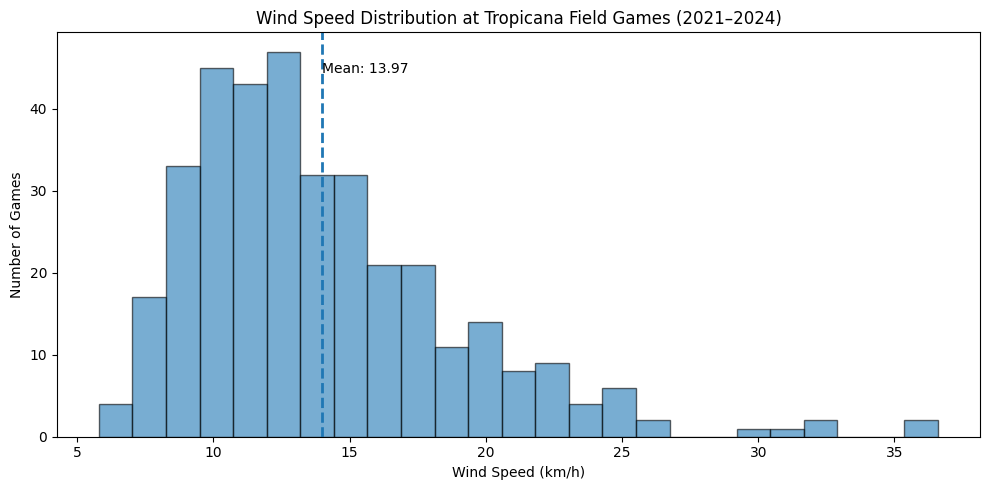

In [45]:
import matplotlib.pyplot as plt
import numpy as np

def hist_with_mean(series, title, xlabel, bins=25):
    s = series.dropna()
    if len(s) == 0:
        print("No data for:", title)
        return
    plt.figure(figsize=(10,5))
    plt.hist(s, bins=bins, edgecolor="black", alpha=0.6)
    m = s.mean()
    plt.axvline(m, linestyle="--", linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of Games")
    plt.text(m, plt.ylim()[1]*0.9, f"Mean: {m:.2f}", ha="left")
    plt.tight_layout()
    plt.show()

if "wind" in games_w.columns:
    hist_with_mean(games_w["wind"], "Wind Speed Distribution at Tropicana Field Games (2021–2024)", "Wind Speed (km/h)")


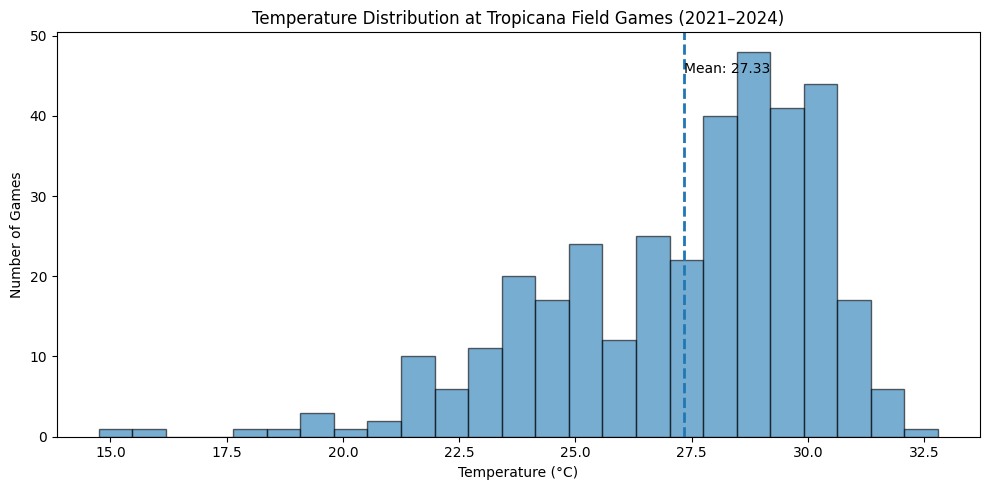

In [46]:
hist_with_mean(games_w["temp"], "Temperature Distribution at Tropicana Field Games (2021–2024)", "Temperature (°C)")


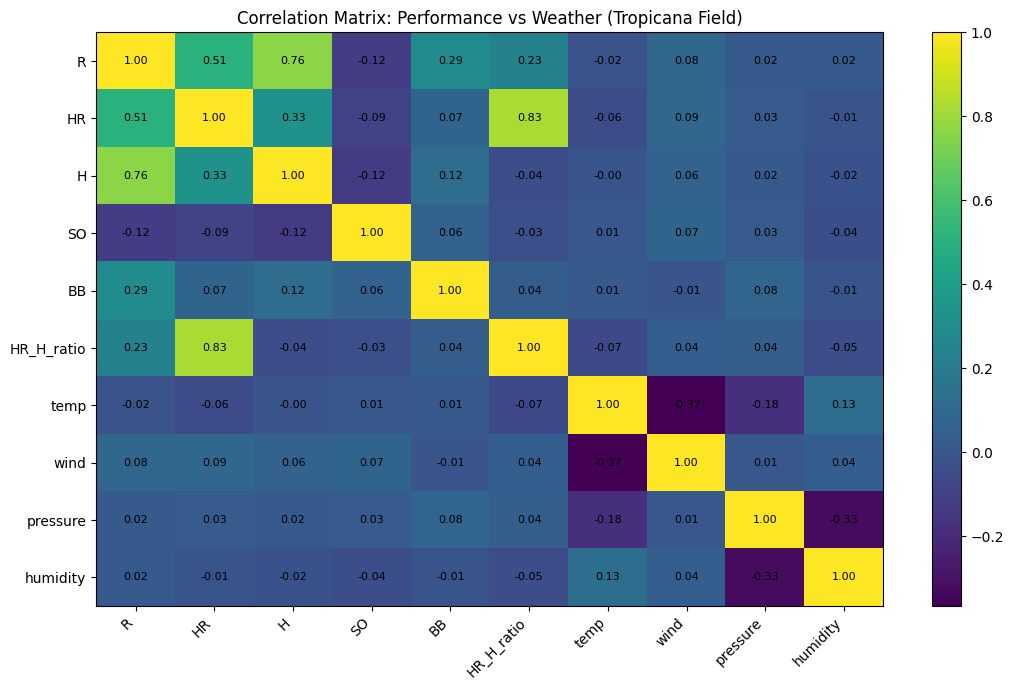

In [47]:
perf_cols = [c for c in ["R","HR","H","SO","BB","HR_H_ratio"] if c in games_w.columns]
wx_cols   = [c for c in ["temp","wind","pressure","humidity"] if c in games_w.columns]

corr_df = games_w[perf_cols + wx_cols].dropna()
if len(corr_df) < 5:
    print("Not enough merged rows to compute correlations (check weather merge).")
else:
    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(11,7))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Matrix: Performance vs Weather (Tropicana Field)")
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


<Figure size 700x400 with 0 Axes>

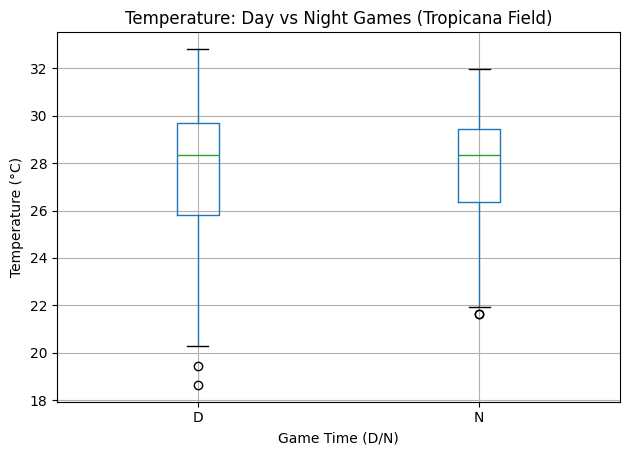

<Figure size 700x400 with 0 Axes>

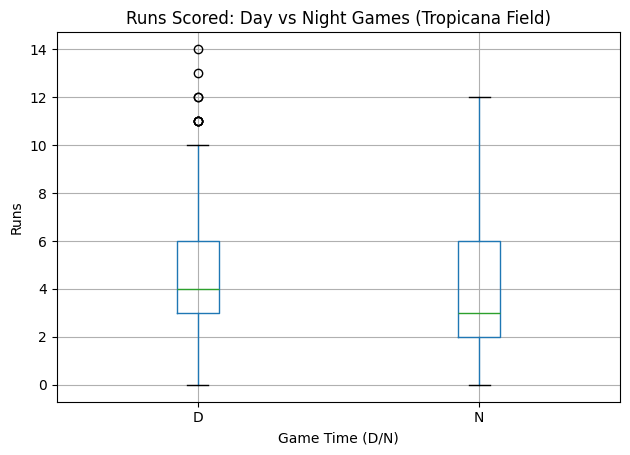

In [48]:
def boxplot_by_dn(df_, col, title, ylabel):
    d = df_.dropna(subset=[col, "DN"])
    d = d[d["DN"].isin(["D","N"])]
    if d.empty:
        print("No day/night data for:", col)
        return
    plt.figure(figsize=(7,4))
    d.boxplot(column=col, by="DN")
    plt.title(title)
    plt.suptitle("")
    plt.xlabel("Game Time (D/N)")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

if "DN" in games_w.columns:
    boxplot_by_dn(games_w, "temp", "Temperature: Day vs Night Games (Tropicana Field)", "Temperature (°C)")
    if "R" in games_w.columns:
        boxplot_by_dn(games_w, "R", "Runs Scored: Day vs Night Games (Tropicana Field)", "Runs")


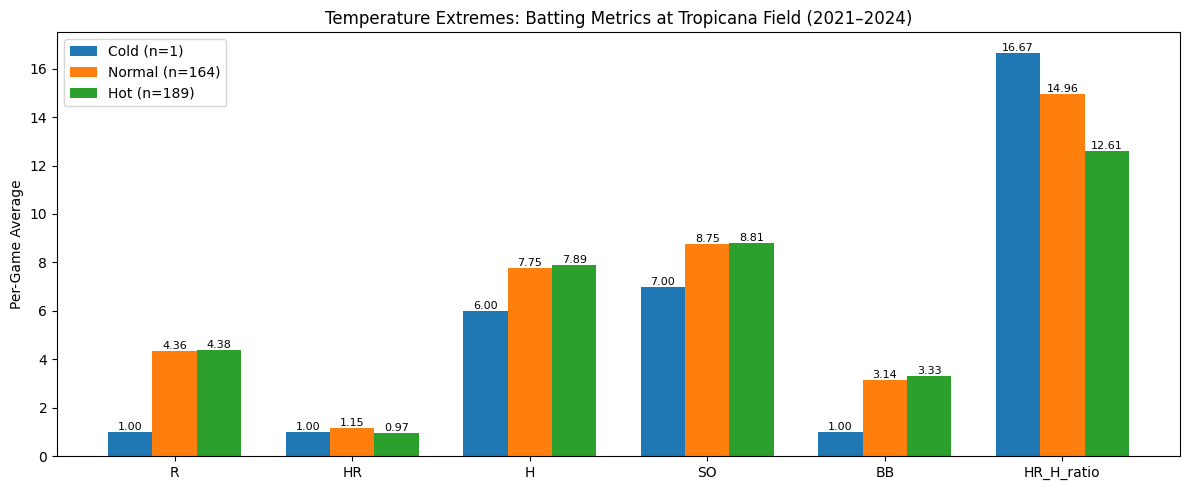

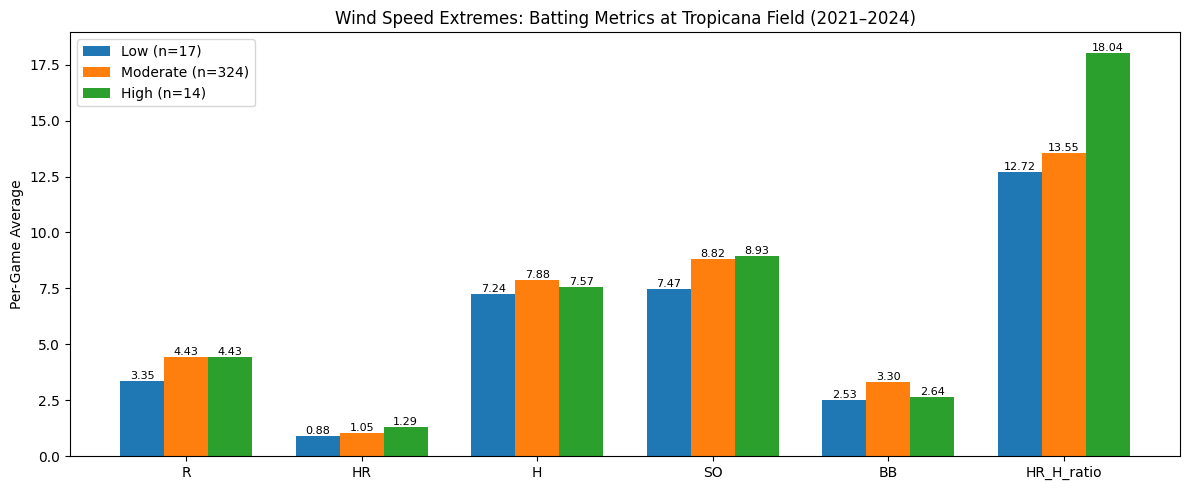

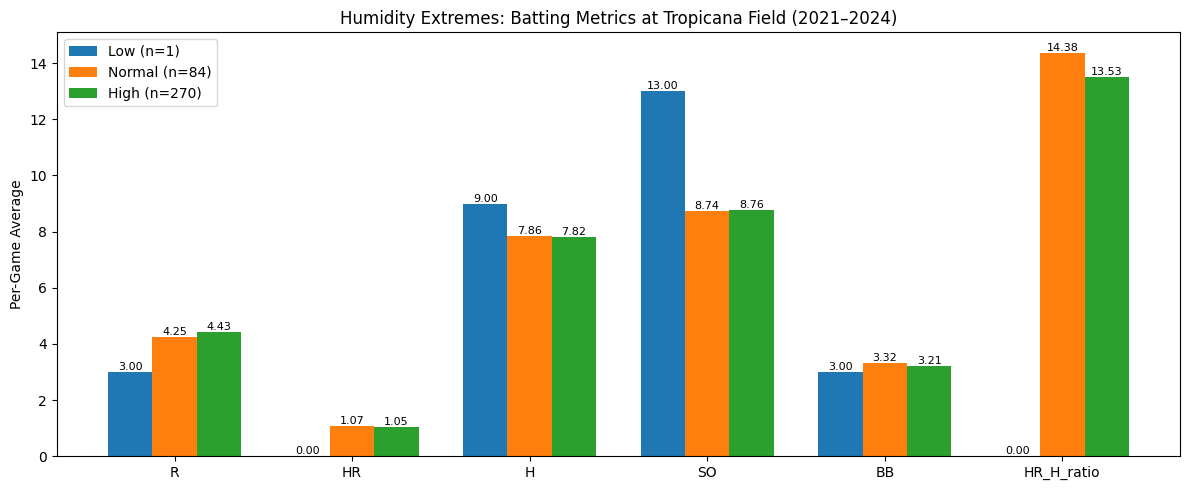

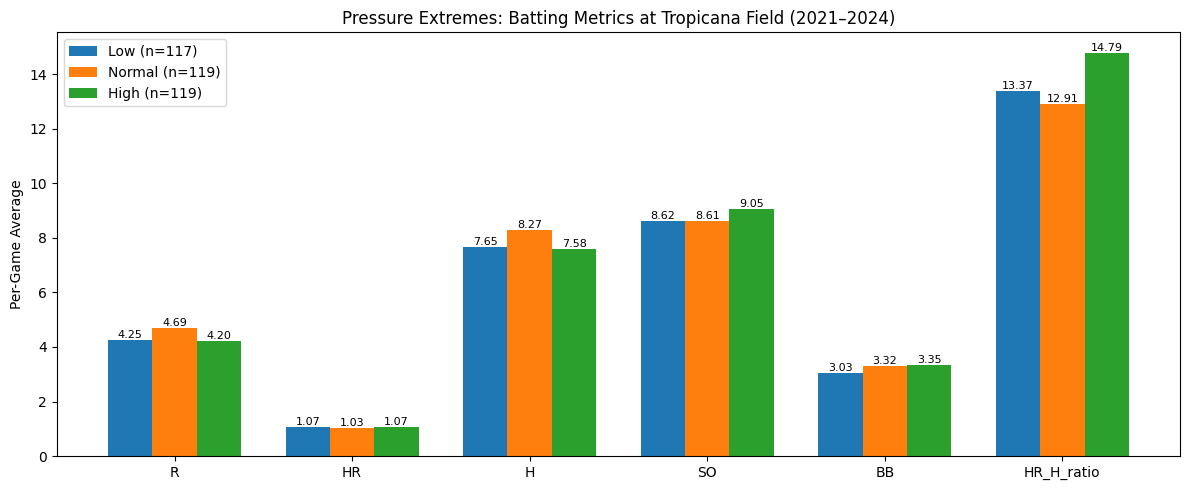

In [49]:
metrics = [c for c in ["R","HR","H","SO","BB","HR_H_ratio"] if c in games_w.columns]

def grouped_extreme_bar(data, wx_col, bins, labels, title):
    d = data.dropna(subset=[wx_col] + metrics).copy()
    if d.empty:
        print(f"Skipping {wx_col}: no data")
        return

    d["wx_bin"] = pd.cut(d[wx_col], bins=bins, labels=labels, include_lowest=True)
    agg = d.groupby("wx_bin")[metrics].mean()
    counts = d["wx_bin"].value_counts().reindex(labels).fillna(0).astype(int)

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(12,5))
    for i, lab in enumerate(labels):
        if lab not in agg.index:
            continue
        offs = (i - (len(labels)-1)/2)*width
        vals = agg.loc[lab].values
        plt.bar(x + offs, vals, width, label=f"{lab} (n={counts.loc[lab]})")
        for j, v in enumerate(vals):
            if np.isfinite(v):
                plt.text(x[j] + offs, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    plt.xticks(x, metrics)
    plt.ylabel("Per-Game Average")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Temperature extremes
grouped_extreme_bar(
    games_w, "temp",
    [-np.inf, 15, 28, np.inf],
    ["Cold","Normal","Hot"],
    "Temperature Extremes: Batting Metrics at Tropicana Field (2021–2024)"
)

# Wind extremes
if "wind" in games_w.columns:
    grouped_extreme_bar(
        games_w, "wind",
        [-np.inf, 8, 24, np.inf],
        ["Low","Moderate","High"],
        "Wind Speed Extremes: Batting Metrics at Tropicana Field (2021–2024)"
    )

# Humidity extremes
if "humidity" in games_w.columns:
    grouped_extreme_bar(
        games_w, "humidity",
        [-np.inf, 40, 70, np.inf],
        ["Low","Normal","High"],
        "Humidity Extremes: Batting Metrics at Tropicana Field (2021–2024)"
    )

# Pressure extremes (quantiles)
if "pressure" in games_w.columns:
    q1, q2 = games_w["pressure"].quantile([0.33, 0.66])
    grouped_extreme_bar(
        games_w, "pressure",
        [-np.inf, q1, q2, np.inf],
        ["Low","Normal","High"],
        "Pressure Extremes: Batting Metrics at Tropicana Field (2021–2024)"
    )


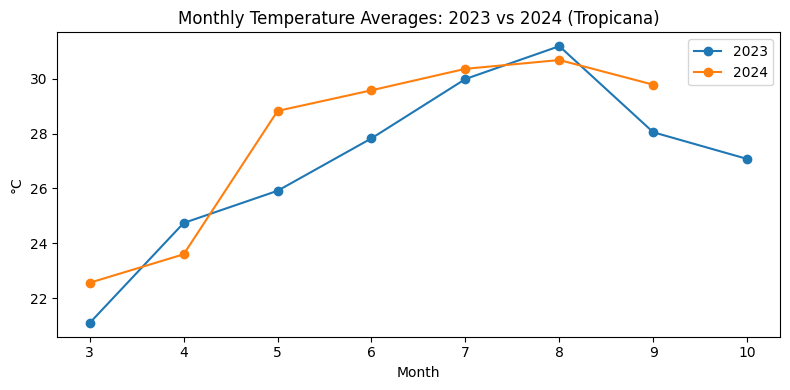

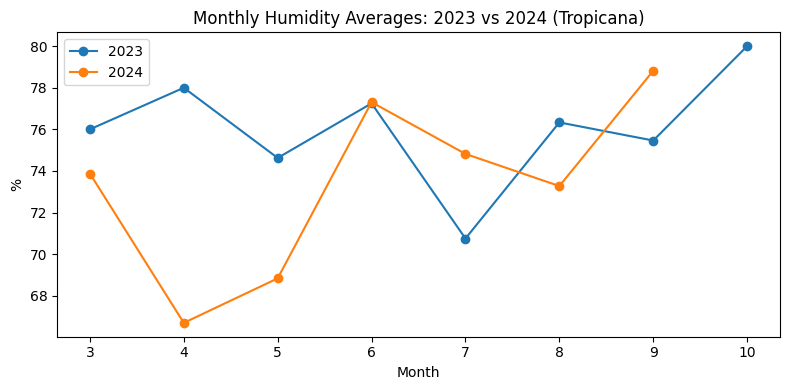

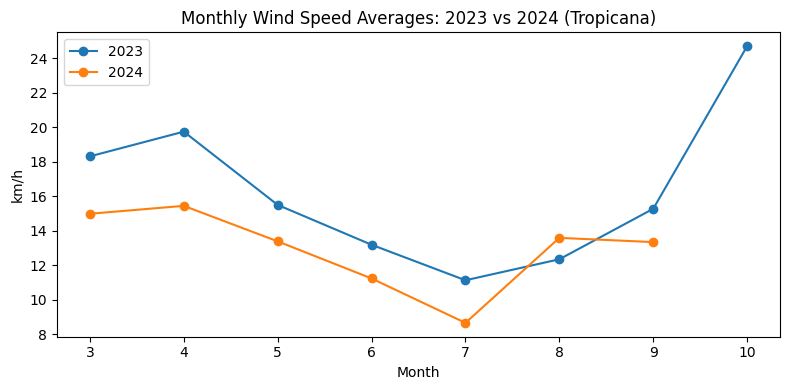

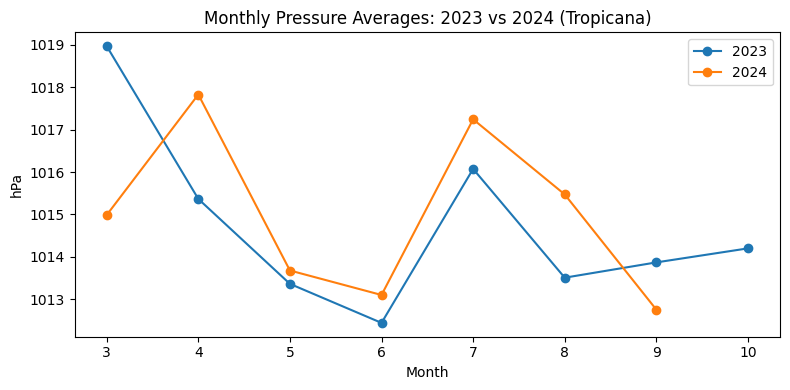

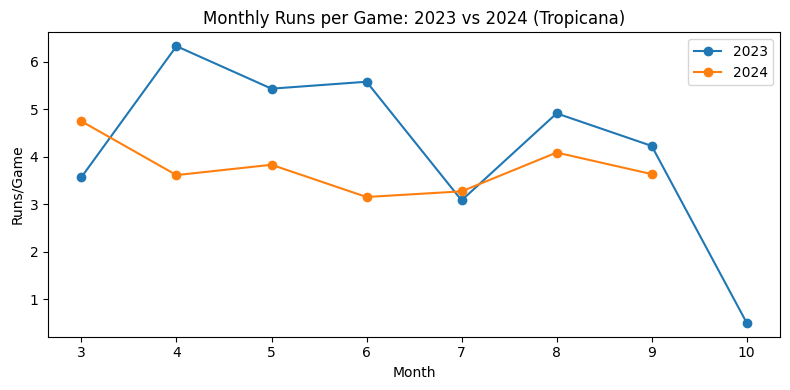

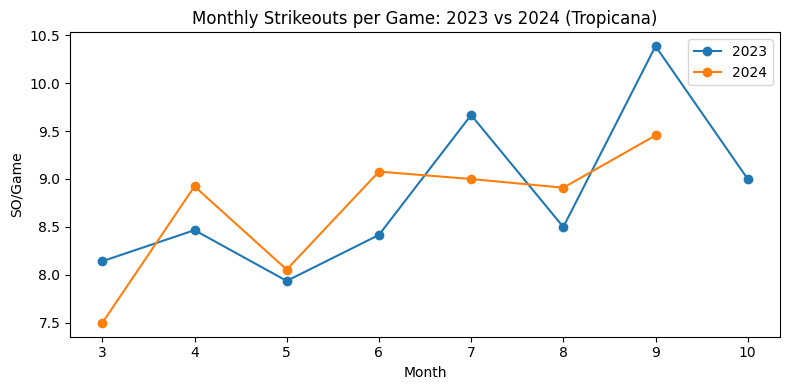

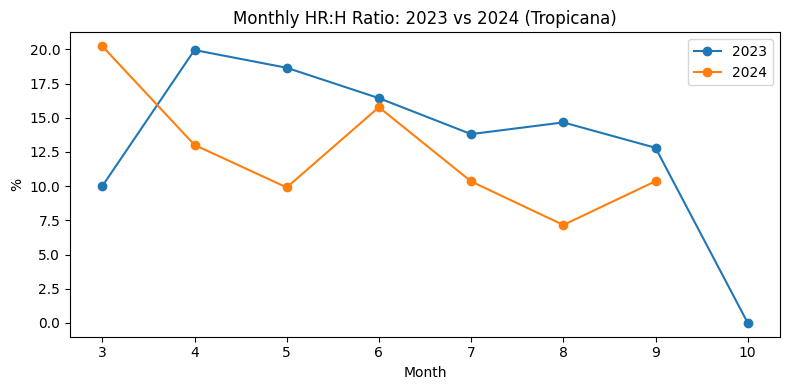

In [50]:
games_w["date"] = pd.to_datetime(games_w["date_only"])
games_w["year"] = games_w["date"].dt.year
games_w["month"] = games_w["date"].dt.month

def monthly_line(col, title, ylabel):
    if col not in games_w.columns:
        return
    g = games_w.dropna(subset=[col]).groupby(["year","month"])[col].mean().reset_index()
    g23 = g[g["year"]==2023].set_index("month")[col]
    g24 = g[g["year"]==2024].set_index("month")[col]

    plt.figure(figsize=(8,4))
    plt.plot(g23.index, g23.values, marker="o", label="2023")
    plt.plot(g24.index, g24.values, marker="o", label="2024")
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Weather
monthly_line("temp", "Monthly Temperature Averages: 2023 vs 2024 (Tropicana)", "°C")
if "humidity" in games_w.columns:
    monthly_line("humidity", "Monthly Humidity Averages: 2023 vs 2024 (Tropicana)", "%")
if "wind" in games_w.columns:
    monthly_line("wind", "Monthly Wind Speed Averages: 2023 vs 2024 (Tropicana)", "km/h")
if "pressure" in games_w.columns:
    monthly_line("pressure", "Monthly Pressure Averages: 2023 vs 2024 (Tropicana)", "hPa")

# Performance
monthly_line("R", "Monthly Runs per Game: 2023 vs 2024 (Tropicana)", "Runs/Game")
if "SO" in games_w.columns:
    monthly_line("SO", "Monthly Strikeouts per Game: 2023 vs 2024 (Tropicana)", "SO/Game")
if "HR_H_ratio" in games_w.columns:
    monthly_line("HR_H_ratio", "Monthly HR:H Ratio: 2023 vs 2024 (Tropicana)", "%")


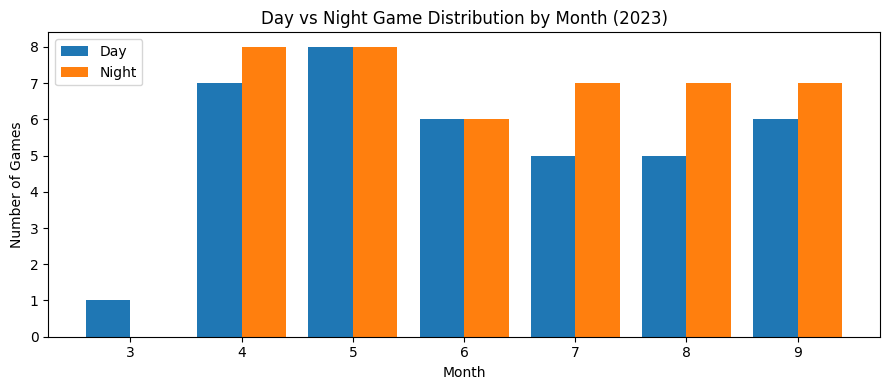

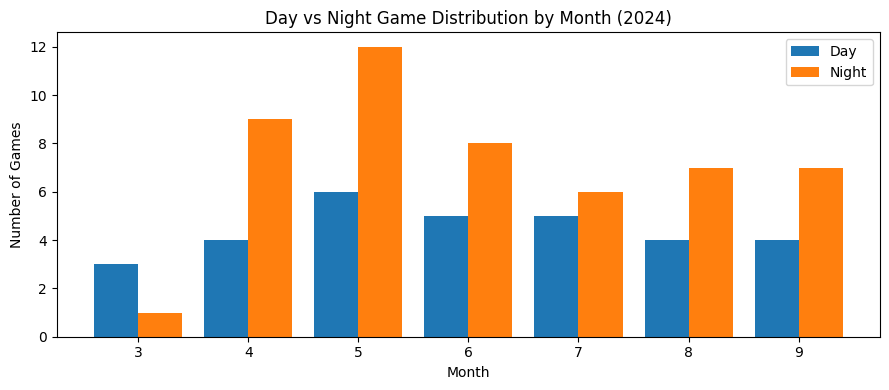

In [51]:
if "DN" in games_w.columns and games_w["DN"].isin(["D","N"]).any():
    for yr in [2023, 2024]:
        tmp = games_w[(games_w["year"]==yr) & (games_w["DN"].isin(["D","N"]))].copy()
        if tmp.empty:
            continue
        counts = tmp.pivot_table(index="month", columns="DN", values="date_only", aggfunc="count").fillna(0)

        plt.figure(figsize=(9,4))
        months = counts.index.values
        d_vals = counts["D"].values if "D" in counts.columns else np.zeros_like(months, dtype=float)
        n_vals = counts["N"].values if "N" in counts.columns else np.zeros_like(months, dtype=float)

        plt.bar(months - 0.2, d_vals, width=0.4, label="Day")
        plt.bar(months + 0.2, n_vals, width=0.4, label="Night")
        plt.title(f"Day vs Night Game Distribution by Month ({yr})")
        plt.xlabel("Month")
        plt.ylabel("Number of Games")
        plt.legend()
        plt.tight_layout()
        plt.show()


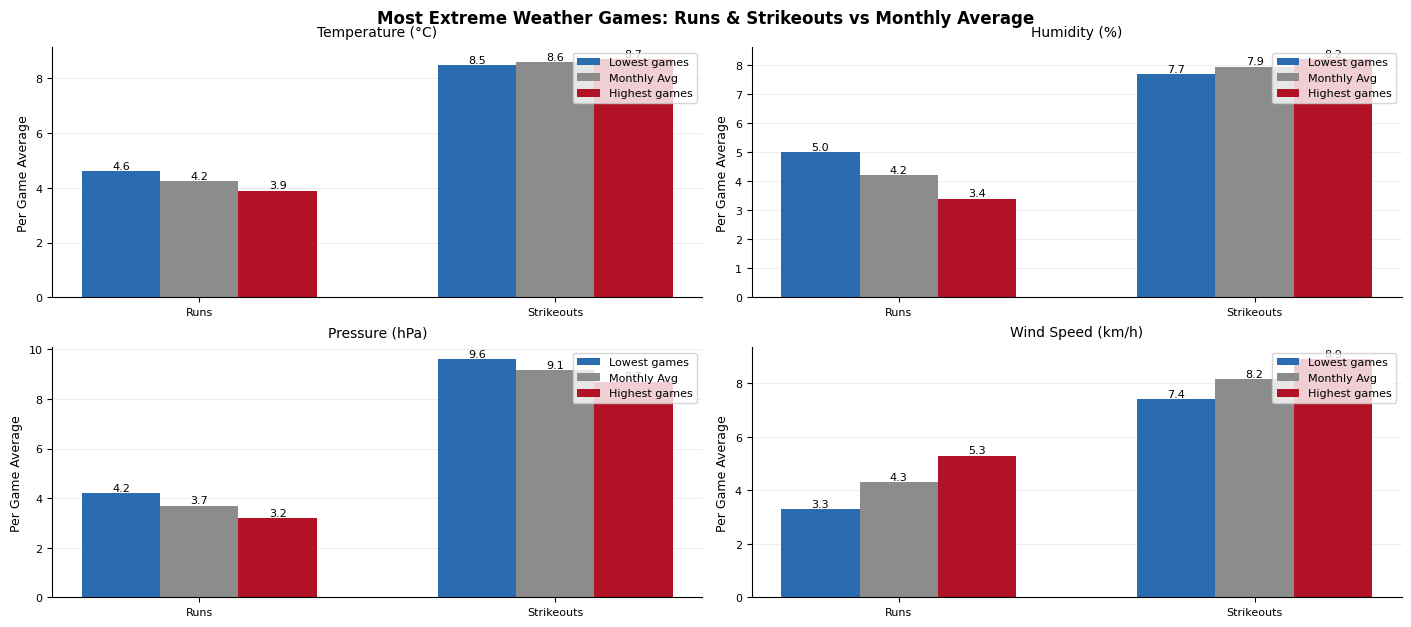

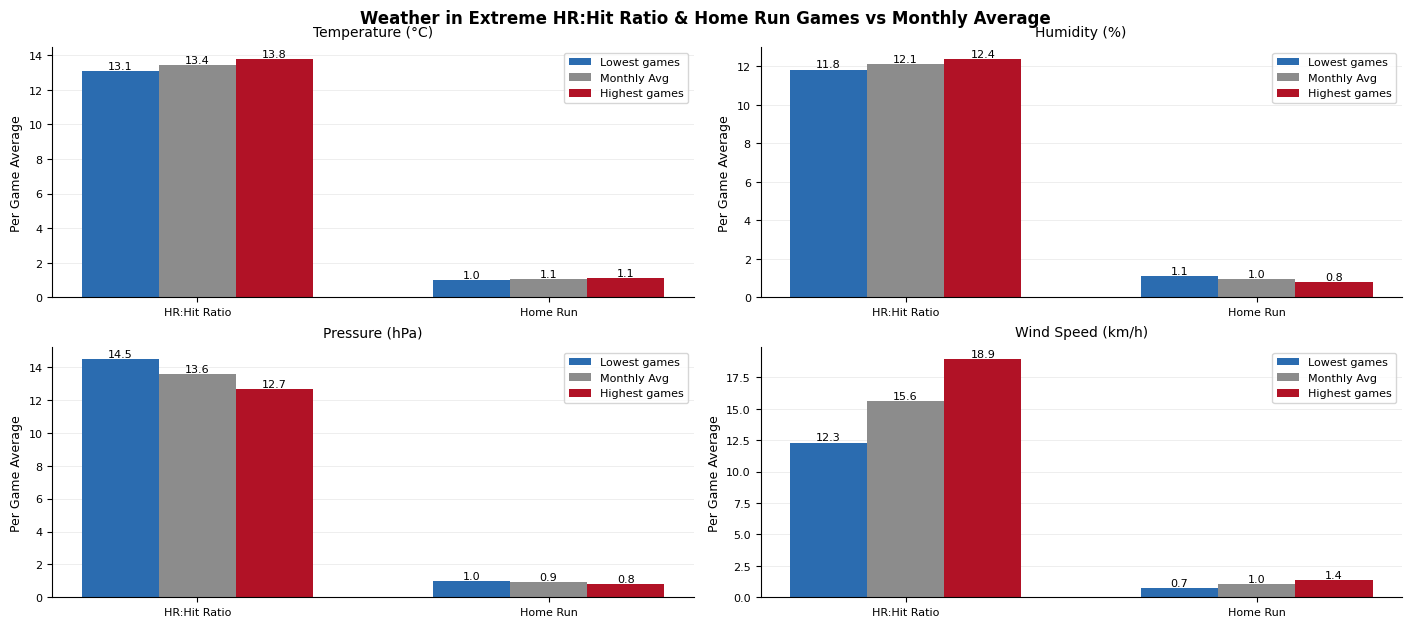

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- STYLE to match the slide ----
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Fixed palette like the slide
C_LOW   = "#2b6cb0"   # blue
C_AVG   = "#8c8c8c"   # gray
C_HIGH  = "#b11226"   # red

def _monthly_avg_for_games(d, metric):
    """Monthly mean of metric for each game's month."""
    monthly = d.groupby("month_period")[metric].mean()
    return d["month_period"].map(monthly)

def _extreme_triplet(d, wx_col, metric, n=10):
    """
    Returns (low_mean, monthly_mean_for_low_months, high_mean, monthly_mean_for_high_months)
    computed on bottom/top n games by wx_col.
    """
    d = d.dropna(subset=[wx_col, metric, "month_period"]).copy()
    if len(d) == 0:
        return None

    d_sorted = d.sort_values(wx_col)
    low_games = d_sorted.head(n).copy()
    high_games = d_sorted.tail(n).copy()

    low_games["monthly_avg"] = _monthly_avg_for_games(low_games, metric)
    high_games["monthly_avg"] = _monthly_avg_for_games(high_games, metric)

    low_mean = low_games[metric].mean()
    low_monthly = low_games["monthly_avg"].mean()

    high_mean = high_games[metric].mean()
    high_monthly = high_games["monthly_avg"].mean()

    return low_mean, low_monthly, high_mean, high_monthly, len(low_games), len(high_games)

def _subplot_extreme(ax, d, wx_col, title, metrics, n=10, ylab="Per Game Average",
                     legend_labels=("Lowest games","Monthly Avg","Highest games")):
    """
    One small subplot: grouped bars for each metric (3 bars: low/monthly/high)
    """
    # Gridlines like slide
    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.25)
    ax.set_axisbelow(True)

    # Layout for grouped bars
    x = np.arange(len(metrics))
    w = 0.22

    # Compute bars
    lows, avgs, highs = [], [], []
    for m in metrics:
        out = _extreme_triplet(d, wx_col, m, n=n)
        if out is None:
            lows.append(np.nan); avgs.append(np.nan); highs.append(np.nan)
        else:
            low_mean, low_monthly, high_mean, high_monthly, _, _ = out
            # For the middle bar, use "Monthly Avg" from the same months (use average of low/high monthly avgs)
            # The slide uses one middle bar; we’ll average the two monthly baselines.
            mid = np.nanmean([low_monthly, high_monthly])
            lows.append(low_mean); avgs.append(mid); highs.append(high_mean)

    lows = np.array(lows, dtype=float)
    avgs = np.array(avgs, dtype=float)
    highs = np.array(highs, dtype=float)

    # Bars
    b1 = ax.bar(x - w, lows,  width=w, color=C_LOW,  label=legend_labels[0])
    b2 = ax.bar(x,     avgs,  width=w, color=C_AVG,  label=legend_labels[1])
    b3 = ax.bar(x + w, highs, width=w, color=C_HIGH, label=legend_labels[2])

    # Value labels
    def label_bars(bars):
        for b in bars:
            h = b.get_height()
            if not np.isfinite(h): 
                continue
            ax.text(b.get_x() + b.get_width()/2, h, f"{h:.1f}",
                    ha="center", va="bottom", fontsize=8)
    label_bars(b1); label_bars(b2); label_bars(b3)

    ax.set_title(title, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel(ylab)

    # Compact legend in upper right like slide
    ax.legend(frameon=True, loc="upper right")

def make_extreme_games_panels(games_w, n=10):
    """
    Creates the two-panel layout matching the screenshot style.
    Requires games_w columns:
      - date/date_only -> for month_period
      - weather: temp, humidity, pressure, wind (optional wind)
      - performance: R, SO, HR, H, HR_H_ratio
    """
    d = games_w.copy()

    # Ensure month_period
    if "date" not in d.columns:
        d["date"] = pd.to_datetime(d["date_only"])
    d["month_period"] = d["date"].dt.to_period("M").astype(str)

    # --- Panel A: Runs & Strikeouts vs Monthly Avg (2x2) ---
    fig1, axs = plt.subplots(2, 2, figsize=(14, 6), constrained_layout=True)
    fig1.suptitle("Most Extreme Weather Games: Runs & Strikeouts vs Monthly Average",
                  fontsize=12, fontweight="bold", y=1.02)

    metrics_rs = []
    if "R" in d.columns: metrics_rs.append("R")
    if "SO" in d.columns: metrics_rs.append("SO")
    # Match slide labels "Runs", "Strikeouts"
    pretty_metrics_rs = ["Runs" if m=="R" else ("Strikeouts" if m=="SO" else m) for m in metrics_rs]

    # Helper to pass pretty metric labels but use real cols
    def subplot_rs(ax, wx_col, title):
        # Compute using real metric columns, but relabel x ticks
        _subplot_extreme(ax, d, wx_col, title, metrics_rs, n=n)
        ax.set_xticklabels(pretty_metrics_rs)

    if "temp" in d.columns:
        subplot_rs(axs[0,0], "temp", "Temperature (°C)")
    else:
        axs[0,0].set_visible(False)

    if "humidity" in d.columns:
        subplot_rs(axs[0,1], "humidity", "Humidity (%)")
    else:
        axs[0,1].set_visible(False)

    if "pressure" in d.columns:
        subplot_rs(axs[1,0], "pressure", "Pressure (hPa)")
    else:
        axs[1,0].set_visible(False)

    if "wind" in d.columns:
        subplot_rs(axs[1,1], "wind", "Wind Speed (km/h)")
    else:
        axs[1,1].set_visible(False)

    plt.show()

    # --- Panel B: HR:Hit Ratio & Home Runs vs Monthly Avg (2x2) ---
    fig2, axs2 = plt.subplots(2, 2, figsize=(14, 6), constrained_layout=True)
    fig2.suptitle("Weather in Extreme HR:Hit Ratio & Home Run Games vs Monthly Average",
                  fontsize=12, fontweight="bold", y=1.02)

    # Ensure HR_H_ratio exists
    if "HR_H_ratio" not in d.columns and {"HR","H"}.issubset(d.columns):
        d["HR_H_ratio"] = np.where(d["H"] > 0, 100*d["HR"]/d["H"], np.nan)

    metrics_hr = []
    if "HR_H_ratio" in d.columns: metrics_hr.append("HR_H_ratio")
    if "HR" in d.columns: metrics_hr.append("HR")

    # Pretty labels
    pretty_metrics_hr = ["HR:Hit Ratio" if m=="HR_H_ratio" else ("Home Run" if m=="HR" else m)
                         for m in metrics_hr]

    def subplot_hr(ax, wx_col, title):
        _subplot_extreme(ax, d, wx_col, title, metrics_hr, n=n)
        ax.set_xticklabels(pretty_metrics_hr)

    if "temp" in d.columns:
        subplot_hr(axs2[0,0], "temp", "Temperature (°C)")
    else:
        axs2[0,0].set_visible(False)

    if "humidity" in d.columns:
        subplot_hr(axs2[0,1], "humidity", "Humidity (%)")
    else:
        axs2[0,1].set_visible(False)

    if "pressure" in d.columns:
        subplot_hr(axs2[1,0], "pressure", "Pressure (hPa)")
    else:
        axs2[1,0].set_visible(False)

    # For Tropicana, you might not have a "wind toward monster" proxy.
    # We'll use wind speed if present; otherwise hide.
    if "wind" in d.columns:
        subplot_hr(axs2[1,1], "wind", "Wind Speed (km/h)")
    else:
        axs2[1,1].set_visible(False)

    plt.show()

# ---- RUN IT ----
make_extreme_games_panels(games_w, n=10)
